# Global XXZ Ground-State Entanglement Scan

This notebook translates the Mathematica scan into Python. It scans every fixed-`Nup` sector,
finds the true lowest-energy state at each anisotropy `Delta`, and then computes the half-chain
entanglement entropy of that winning state. The `J2` and `Delta2` couplings are kept in place
for later use, but are set to zero by default here.

Set `MAX_DELTA_POINTS` to a small integer if you want a fast preview instead of the full sweep.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb
from itertools import combinations
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh
from scipy.linalg import svdvals

try:
    from numba import njit
except Exception:
    def njit(*args, **kwargs):
        if args and len(args) == 1 and callable(args[0]) and not kwargs:
            return args[0]

        def decorator(func):
            return func

        return decorator


@njit(cache=True)
def _build_cut_map_numba(states, L, ell):
    dim = states.shape[0]
    row_a = np.empty(dim, dtype=np.int32)
    row_b = np.empty(dim, dtype=np.int32)
    left_shift = L - ell
    left_mask = (np.uint64(1) << np.uint64(left_shift)) - np.uint64(1)
    right_mask = (np.uint64(1) << np.uint64(ell)) - np.uint64(1)

    for i in range(dim):
        state = states[i]
        row_a[i] = int((state >> np.uint64(left_shift)) & left_mask)
        row_b[i] = int(state & right_mask)

    return row_a, row_b


@njit(cache=True)
def _build_hamiltonian_triplets(states, index_map, L, pairs1, pairs2, J1xy, J1z, J2xy, J2z, kind_flag):
    dim = states.shape[0]
    n1 = pairs1.shape[0]
    n2 = pairs2.shape[0]
    if kind_flag == 0:
        max_nnz = dim + dim * n1
    else:
        max_nnz = dim + dim * (n1 + n2)

    rows = np.empty(max_nnz, dtype=np.int32)
    cols = np.empty(max_nnz, dtype=np.int32)
    vals = np.empty(max_nnz, dtype=np.float64)
    diag = np.zeros(dim, dtype=np.float64)
    one = np.uint64(1)
    cursor = 0

    for i in range(dim):
        state = states[i]

        for p in range(n1):
            a = pairs1[p, 0]
            b = pairs1[p, 1]
            pa = np.uint64(L - 1 - a)
            pb = np.uint64(L - 1 - b)
            bit_a = (state >> pa) & one
            bit_b = (state >> pb) & one
            if bit_a == bit_b:
                diag[i] += J1z / 4.0
            else:
                diag[i] -= J1z / 4.0
                if J1xy != 0.0:
                    flipped = state ^ ((one << pa) | (one << pb))
                    j = index_map[np.int64(flipped)]
                    rows[cursor] = i
                    cols[cursor] = j
                    vals[cursor] = J1xy / 2.0
                    cursor += 1

        if kind_flag == 1:
            for p in range(n2):
                a = pairs2[p, 0]
                b = pairs2[p, 1]
                pa = np.uint64(L - 1 - a)
                pb = np.uint64(L - 1 - b)
                bit_a = (state >> pa) & one
                bit_b = (state >> pb) & one
                if bit_a == bit_b:
                    diag[i] += J2z / 4.0
                else:
                    diag[i] -= J2z / 4.0
                    if J2xy != 0.0:
                        flipped = state ^ ((one << pa) | (one << pb))
                        j = index_map[np.int64(flipped)]
                        rows[cursor] = i
                        cols[cursor] = j
                        vals[cursor] = J2xy / 2.0
                        cursor += 1

    for i in range(dim):
        rows[cursor] = i
        cols[cursor] = i
        vals[cursor] = diag[i]
        cursor += 1

    return rows[:cursor], cols[:cursor], vals[:cursor]


class FastXXZChain:
    """Optimized fixed-Nup XXZ chain with cached basis, Hamiltonian, and entropy maps."""

    def __init__(self, L, Nup, periodic=True, J1xy=1.0, J1z=0.5, J2xy=0.0, J2z=0.0):
        self.L = int(L)
        self.Nup = int(Nup)
        self.periodic = bool(periodic)
        self.J1xy = float(J1xy)
        self.J1z = float(J1z)
        self.J2xy = float(J2xy)
        self.J2z = float(J2z)

        self.states = self._build_basis_states()
        self.index_map = self._build_index_map()
        self.pairs1 = np.asarray(self._pairs(1), dtype=np.int32)
        self.pairs2 = np.asarray(self._pairs(2), dtype=np.int32)
        self._entropy_cache = {}
        self._ham_components_cache = {}

    def _build_basis_states(self):
        states = []
        for positions in combinations(range(self.L), self.Nup):
            value = 0
            for site in positions:
                value |= 1 << (self.L - 1 - site)
            states.append(value)
        return np.asarray(states, dtype=np.uint64)

    def _build_index_map(self):
        size = 1 << self.L
        index_map = -np.ones(size, dtype=np.int32)
        for i, state in enumerate(self.states):
            index_map[int(state)] = i
        return index_map

    def _pairs(self, order):
        if order == 1:
            if self.periodic:
                return [(i, (i + 1) % self.L) for i in range(self.L)]
            return [(i, i + 1) for i in range(self.L - 1)]
        if order == 2:
            if self.periodic:
                return [(i, (i + 2) % self.L) for i in range(self.L)]
            return [(i, i + 2) for i in range(self.L - 2)]
        raise ValueError('order must be 1 or 2')

    def hilbert_dimension(self):
        return int(self.states.size)

    def build_hamiltonian_components(self, kind='nnn'):
        key = (kind, float(self.J1xy), float(self.J2xy))
        if key in self._ham_components_cache:
            return self._ham_components_cache[key]

        kind_flag = 0 if kind == 'nn' else 1
        dim = self.hilbert_dimension()

        # XY part (flip terms) with current J1xy/J2xy, but zero Z couplings
        rows_xy, cols_xy, vals_xy = _build_hamiltonian_triplets(
            self.states,
            self.index_map,
            self.L,
            self.pairs1,
            self.pairs2,
            self.J1xy,
            0.0,
            self.J2xy,
            0.0,
            kind_flag,
        )
        H_xy = coo_matrix((vals_xy, (rows_xy, cols_xy)), shape=(dim, dim)).tocsr()

        # Z contributions separated: J1z=1, J2z=0
        rows_z1, cols_z1, vals_z1 = _build_hamiltonian_triplets(
            self.states,
            self.index_map,
            self.L,
            self.pairs1,
            self.pairs2,
            0.0,
            1.0,
            0.0,
            0.0,
            kind_flag,
        )
        H_z1 = coo_matrix((vals_z1, (rows_z1, cols_z1)), shape=(dim, dim)).tocsr()

        # Z contributions for next-nearest J2z (unit)
        rows_z2, cols_z2, vals_z2 = _build_hamiltonian_triplets(
            self.states,
            self.index_map,
            self.L,
            self.pairs1,
            self.pairs2,
            0.0,
            0.0,
            0.0,
            1.0,
            kind_flag,
        )
        H_z2 = coo_matrix((vals_z2, (rows_z2, cols_z2)), shape=(dim, dim)).tocsr()

        self._ham_components_cache[key] = (H_xy, H_z1, H_z2)
        return self._ham_components_cache[key]

    def build_hamiltonian(self, kind='nnn'):
        H_xy, H_z1, H_z2 = self.build_hamiltonian_components(kind=kind)
        return H_xy + (self.J1z * H_z1) + (self.J2z * H_z2)

    def ground_state(self, kind='nnn'):
        H = self.build_hamiltonian(kind=kind)
        if H.shape[0] == 1:
            return float(H[0, 0]), np.array([1.0], dtype=float)
        eigvals, eigvecs = eigsh(H, k=1, which='SA', tol=1e-12, maxiter=100000)
        return float(eigvals[0]), eigvecs[:, 0]

    def _cut_map(self, ell):
        if ell in self._entropy_cache:
            return self._entropy_cache[ell]

        row_a, row_b = _build_cut_map_numba(self.states, self.L, ell)
        mapping = {
            'rowA': row_a,
            'rowB': row_b,
            'dimA': 1 << ell,
            'dimB': 1 << (self.L - ell),
        }
        self._entropy_cache[ell] = mapping
        return mapping

    def entropy_curve(self, kind='nnn', blocks=None):
        ground_energy, sector_state = self.ground_state(kind=kind)
        if blocks is None:
            blocks = range(1, self.L)
        block_list = sorted({int(block) for block in blocks if 0 < block < self.L})

        entropies = np.zeros(len(block_list), dtype=float)
        for i, ell in enumerate(block_list):
            data = self._cut_map(ell)
            psi_matrix = np.zeros((data['dimA'], data['dimB']), dtype=complex)
            psi_matrix[data['rowA'], data['rowB']] = sector_state
            svals = svdvals(psi_matrix)
            probs = svals**2
            probs = probs[probs > 1e-14]
            entropies[i] = float(-np.sum(probs * np.log(probs)))

        block_sizes = np.asarray(block_list, dtype=int)
        upper_bound = np.log(2.0) * np.minimum(block_sizes, self.L - block_sizes)
        return block_sizes, entropies, upper_bound, ground_energy

    def plot_entropy(self, kind='nnn', blocks=None, title=None):
        block_sizes, entropies, upper_bound, ground_energy = self.entropy_curve(kind=kind, blocks=blocks)
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(block_sizes, entropies, marker='o', linewidth=2, label='Entropy')
        ax.plot(block_sizes, upper_bound, '--', linewidth=2, label='Upper Bound')
        ax.set_xlabel('Block size l')
        ax.set_ylabel('S(l)')
        ax.set_title(title or f'Entanglement Entropy (E0 = {ground_energy:.6f})')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()


def half_filling_dimension(L):
    return comb(L, L // 2)


def recommended_max_L(limit_dim=200000):
    best = 0
    for L in range(2, 40, 2):
        if half_filling_dimension(L) <= limit_dim:
            best = L
    return best


Stage 1: global ground-state entanglement scan
L = 10
Boundary = Open
J1 = 1.0
J2 = 0.0
Delta2 = 0.0
Half-chain cut ell = 5
Using parity reduction = False
Building all Nup sectors...
  Building sector Nup = 0
  Building sector Nup = 1
  Building sector Nup = 2
  Building sector Nup = 3
  Building sector Nup = 4
  Building sector Nup = 5
  Building sector Nup = 6
  Building sector Nup = 7
  Building sector Nup = 8
  Building sector Nup = 9
  Building sector Nup = 10
Finished building sectors.
Sector dimensions {Nup, full dim, reduced dim}:
 Nup Full dimension  Reduced dimension
   0              1                  1
   1             10                 10
   2             45                 45
   3            120                120
   4            210                210
   5            252                252
   6            210                210
   7            120                120
   8             45                 45
   9             10                 10
  10              1       

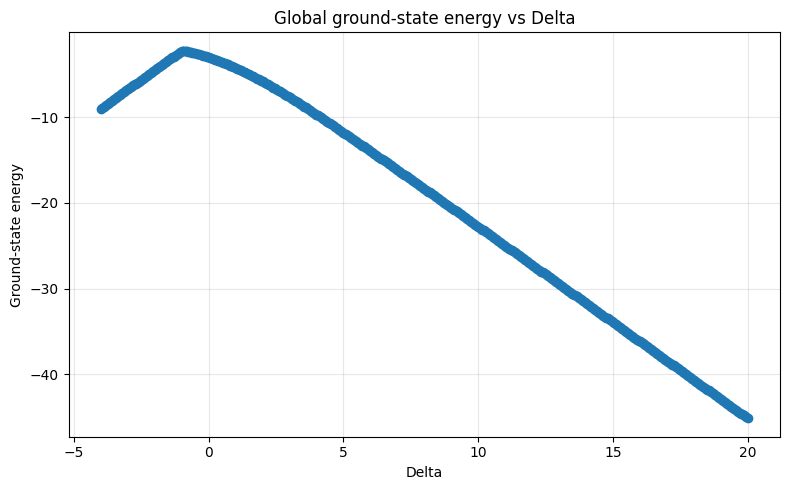

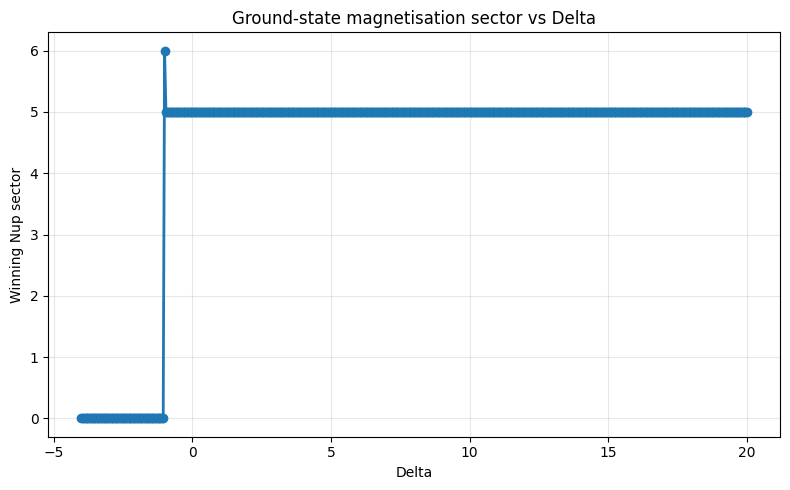

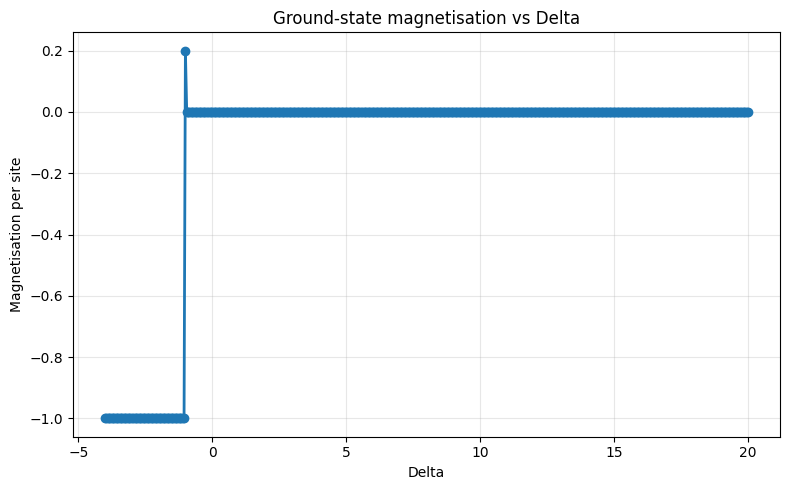

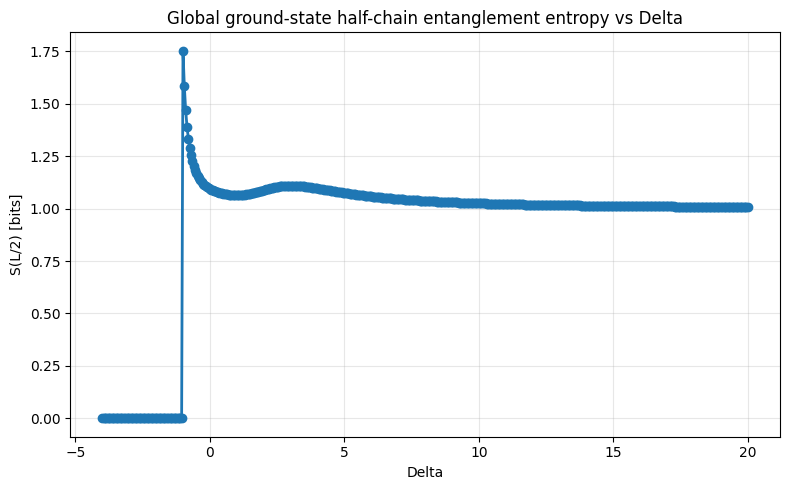

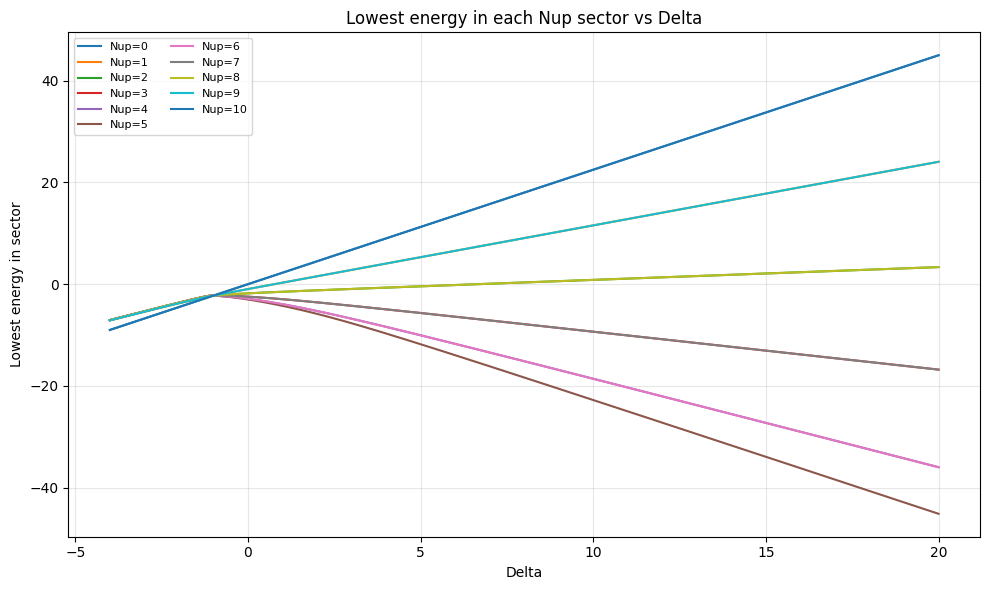

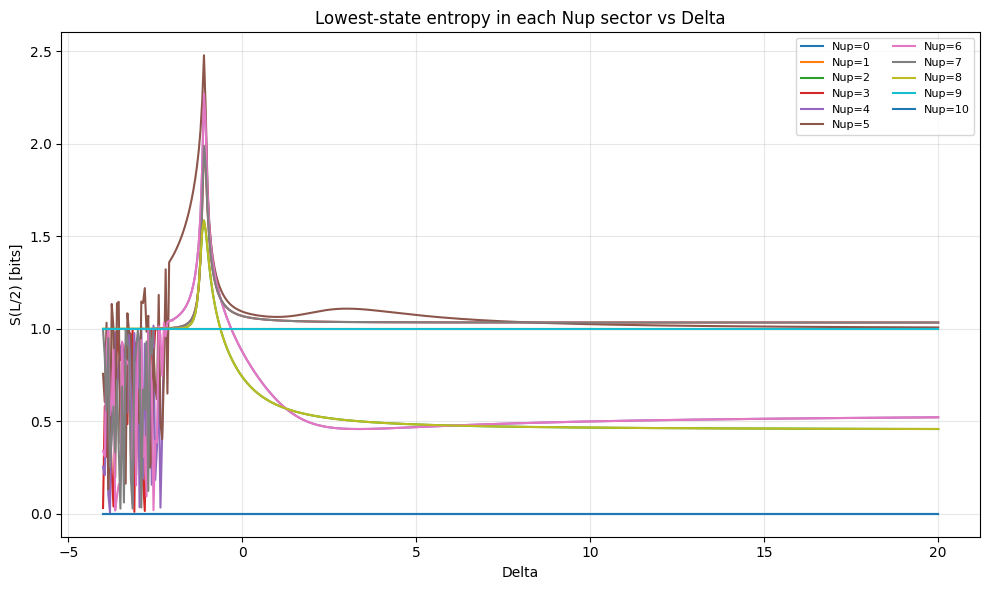

In [5]:
from scipy.sparse import identity

# ================================================================
# STAGE 1: GLOBAL GROUND-STATE ENTANGLEMENT OF THE XXZ CHAIN
# ================================================================
# Goal:
# Scan all Nup sectors and find the true global ground state as a
# function of Delta. Then compute half-chain entanglement.
#
# Current model: XXZ only
# J2 = 0
# Delta2 = 0
#
# NNN terms are kept in the code for later.
# ================================================================

# ================================================================
# 1. USER PARAMETERS
# ================================================================
L = 10
boundary = 'Open'  # Use 'Open' or 'Periodic'
J1 = 1.0          # nearest-neighbour XY coupling
J2 = 0.0          # next-nearest-neighbour XY coupling, kept for later
Delta2 = 0.0      # next-nearest-neighbour ZZ coupling, kept for later
deltaRange = np.round(np.arange(-4.0, 20.0 + 0.025, 0.05), 2)
ellEnt = L // 2
useParity = False
# True = use even parity sector in each Nup sector.
# False = use the full Nup sector.
# For ground states this is usually fine, but if you want the most brute-force check, keep False.
MAX_DELTA_POINTS = None  # set to an integer for a fast preview

print('=' * 60)
print('Stage 1: global ground-state entanglement scan')
print('L =', L)
print('Boundary =', boundary)
print('J1 =', J1)
print('J2 =', J2)
print('Delta2 =', Delta2)
print('Half-chain cut ell =', ellEnt)
print('Using parity reduction =', useParity)
print('=' * 60)

if MAX_DELTA_POINTS is None:
    delta_values = deltaRange
else:
    delta_values = deltaRange[:int(MAX_DELTA_POINTS)]


# ================================================================
# 2. HELPER: BUILD EVEN-PARITY PROJECTION IN ONE Nup SECTOR
# ================================================================

def reverse_chain_state(state, length):
    reflected = 0
    for site in range(length):
        bit = (int(state) >> (length - 1 - site)) & 1
        reflected |= bit << site
    return reflected


def build_even_parity_projection(chain):
    basis_size = chain.hilbert_dimension()
    seen_pairs = set()
    unique_pairs = []

    for i, state in enumerate(chain.states):
        mirrored_state = reverse_chain_state(state, chain.L)
        j = int(chain.index_map[mirrored_state])
        pair = (i, j) if i <= j else (j, i)
        if pair not in seen_pairs:
            seen_pairs.add(pair)
            unique_pairs.append(pair)

    rows = []
    cols = []
    vals = []
    for column, (i, j) in enumerate(unique_pairs):
        if i == j:
            rows.append(i)
            cols.append(column)
            vals.append(1.0)
        else:
            norm = np.sqrt(2.0)
            rows.extend([i, j])
            cols.extend([column, column])
            vals.extend([1.0 / norm, 1.0 / norm])

    return coo_matrix((vals, (rows, cols)), shape=(basis_size, len(unique_pairs))).tocsr()


# ================================================================
# 3. HELPER: BUILD ONE Nup SECTOR
# ================================================================

def build_sector_data(L, Nup, boundary, J1, J2, Delta2, useParity):
    periodic = boundary == 'Periodic'
    chain = FastXXZChain(
        L=L,
        Nup=Nup,
        periodic=periodic,
        J1xy=J1,
        J1z=0.0,
        J2xy=J2,
        J2z=Delta2,
    )

    if useParity:
        projection = build_even_parity_projection(chain)
    else:
        projection = identity(chain.hilbert_dimension(), format='csr', dtype=float)

    entropy_data = [None] * (L + 1)
    for ell in range(1, L):
        entropy_data[ell] = chain._cut_map(ell)

    return {
        'L': L,
        'Nup': Nup,
        'DimFull': chain.hilbert_dimension(),
        'DimReduced': projection.shape[1],
        'Boundary': boundary,
        'J1': J1,
        'J2': J2,
        'Delta2': Delta2,
        'Chain': chain,
        'Projection': projection,
        'EntropyData': entropy_data,
    }


# ================================================================
# 4. HELPER: BUILD HAMILTONIAN IN A SECTOR
# ================================================================

def build_hamiltonian_from_sector(sector, Delta1):
    chain = sector['Chain']
    chain.J1xy = float(sector['J1'])
    chain.J1z = float(Delta1)
    chain.J2xy = float(sector['J2'])
    chain.J2z = float(sector['Delta2'])
    return chain.build_hamiltonian(kind='nnn')


# ================================================================
# 5. HELPER: ENTANGLEMENT ENTROPY IN A SECTOR
# ================================================================

def entanglement_entropy_sector(sector, psi, ell):
    data = sector['EntropyData'][ell]
    if data is None:
        return 0.0

    psi_matrix = coo_matrix(
        (psi, (data['rowA'], data['rowB'])),
        shape=(data['dimA'], data['dimB']),
    ).toarray()
    svals = svdvals(psi_matrix)
    probs = np.clip(svals**2, 0.0, None)
    probs = probs[probs > 1e-14]
    return float(-np.sum(probs * np.log2(probs)))


# ================================================================
# 6. HELPER: LOWEST STATE IN ONE SECTOR
# ================================================================

def lowest_state_in_sector(sector, Delta1):
    H = build_hamiltonian_from_sector(sector, Delta1)
    P = sector['Projection']
    Hred = P.T @ H @ P
    dim_red = Hred.shape[0]

    if dim_red == 1:
        energy = float(Hred[0, 0])
        psi_reduced = np.array([1.0], dtype=complex)
    elif dim_red <= 12:
        vals_dense, vecs_dense = np.linalg.eigh(Hred.toarray())
        idx = int(np.argmin(vals_dense))
        energy = float(vals_dense[idx])
        psi_reduced = vecs_dense[:, idx]
    else:
        vals, vecs = eigsh(Hred, k=1, which='SA', tol=1e-12, maxiter=100000)
        energy = float(vals[0])
        psi_reduced = vecs[:, 0]

    psi_full = np.asarray(P @ psi_reduced).reshape(-1)
    norm = np.linalg.norm(psi_full)
    if norm != 0.0:
        psi_full = psi_full / norm

    entropy = entanglement_entropy_sector(sector, psi_full, ellEnt)
    Sz = sector['Nup'] - L / 2
    magnetisation = (2 * sector['Nup'] / L) - 1

    return {
        'Delta': float(Delta1),
        'Nup': int(sector['Nup']),
        'Sz': float(Sz),
        'Magnetisation': float(magnetisation),
        'Energy': float(energy),
        'Entropy': float(entropy),
        'DimFull': int(sector['DimFull']),
        'DimReduced': int(sector['DimReduced']),
        'State': psi_full,
    }


# ================================================================
# 7. PRECOMPUTE ALL Nup SECTORS
# ================================================================

print('Building all Nup sectors...')
sectors = []
for Nup in range(L + 1):
    print('  Building sector Nup =', Nup)
    sectors.append(build_sector_data(L, Nup, boundary, J1, J2, Delta2, useParity))
print('Finished building sectors.')

sector_dimension_table = [
    (sector['Nup'], sector['DimFull'], sector['DimReduced'])
    for sector in sectors
]

print('Sector dimensions {Nup, full dim, reduced dim}:')
print(f"{'Nup':>4} {'Full dimension':>14} {'Reduced dimension':>18}")
for nup, dim_full, dim_reduced in sector_dimension_table:
    print(f'{nup:>4d} {dim_full:>14d} {dim_reduced:>18d}')


# ================================================================
# 8. SCAN DELTA
# ================================================================

print('Starting Delta scan over all Nup sectors...')
allSectorResultsByDelta = []
for delta in delta_values:
    print('Working on Delta =', delta)
    allSectorResultsByDelta.append([
        lowest_state_in_sector(sector, delta)
        for sector in sectors
    ])
print('Delta scan complete.')


# ================================================================
# 9. SELECT GLOBAL GROUND STATE AT EACH DELTA
# ================================================================

globalGroundResults = []
for sectorResults in allSectorResultsByDelta:
    energies = [result['Energy'] for result in sectorResults]
    idx = int(np.argmin(energies))
    globalGroundResults.append(sectorResults[idx])

groundData = [
    (
        result['Delta'],
        result['Energy'],
        result['Nup'],
        result['Sz'],
        result['Magnetisation'],
        result['Entropy'],
    )
    for result in globalGroundResults
]

groundHeadings = ['Delta', 'Ground energy', 'Winning Nup', 'Sz', 'Magnetisation per site', 'S(L/2)']

print('Global ground-state data:')
print(f"{groundHeadings[0]:>9} {groundHeadings[1]:>15} {groundHeadings[2]:>12} {groundHeadings[3]:>10} {groundHeadings[4]:>24} {groundHeadings[5]:>10}")
for row in groundData:
    print(f'{row[0]:>9.3f} {row[1]:>15.8f} {row[2]:>12d} {row[3]:>10.1f} {row[4]:>24.8f} {row[5]:>10.8f}')


# ================================================================
# 10. PLOT: GLOBAL GROUND-STATE ENERGY VS DELTA
# ================================================================

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([row[0] for row in groundData], [row[1] for row in groundData], marker='o', linewidth=2)
ax.set_xlabel('Delta')
ax.set_ylabel('Ground-state energy')
ax.set_title('Global ground-state energy vs Delta')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ================================================================
# 11. PLOT: WINNING Nup SECTOR VS DELTA
# ================================================================

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([row[0] for row in groundData], [row[2] for row in groundData], marker='o', linewidth=2)
ax.set_xlabel('Delta')
ax.set_ylabel('Winning Nup sector')
ax.set_title('Ground-state magnetisation sector vs Delta')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ================================================================
# 12. PLOT: MAGNETISATION VS DELTA
# ================================================================

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([row[0] for row in groundData], [row[4] for row in groundData], marker='o', linewidth=2)
ax.set_xlabel('Delta')
ax.set_ylabel('Magnetisation per site')
ax.set_title('Ground-state magnetisation vs Delta')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ================================================================
# 13. PLOT: HALF-CHAIN ENTANGLEMENT ENTROPY VS DELTA
# ================================================================

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([row[0] for row in groundData], [row[5] for row in groundData], marker='o', linewidth=2)
ax.set_xlabel('Delta')
ax.set_ylabel('S(L/2) [bits]')
ax.set_title('Global ground-state half-chain entanglement entropy vs Delta')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ================================================================
# 14. OPTIONAL: LOWEST ENERGY IN EACH Nup SECTOR VS DELTA
# ================================================================

sectorEnergyCurves = [
    [
        (delta_values[i], allSectorResultsByDelta[i][s]['Energy'])
        for i in range(len(delta_values))
    ]
    for s in range(len(sectors))
]

fig, ax = plt.subplots(figsize=(10, 6))
for curve, sector in zip(sectorEnergyCurves, sectors):
    ax.plot([point[0] for point in curve], [point[1] for point in curve], linewidth=1.5, label=f"Nup={sector['Nup']}")
ax.set_xlabel('Delta')
ax.set_ylabel('Lowest energy in sector')
ax.set_title('Lowest energy in each Nup sector vs Delta')
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


# ================================================================
# 15. OPTIONAL: LOWEST-STATE ENTROPY IN EACH Nup SECTOR VS DELTA
# ================================================================

sectorEntropyCurves = [
    [
        (delta_values[i], allSectorResultsByDelta[i][s]['Entropy'])
        for i in range(len(delta_values))
    ]
    for s in range(len(sectors))
]

fig, ax = plt.subplots(figsize=(10, 6))
for curve, sector in zip(sectorEntropyCurves, sectors):
    ax.plot([point[0] for point in curve], [point[1] for point in curve], linewidth=1.5, label=f"Nup={sector['Nup']}")
ax.set_xlabel('Delta')
ax.set_ylabel('S(L/2) [bits]')
ax.set_title('Lowest-state entropy in each Nup sector vs Delta')
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


In [7]:
# ================================================================
# FULL SWEEP: Produce and display all graphs for L = 4..16
# To run: set `RUN_FULL_SWEEP = True` and execute this cell.
# WARNING: This performs many diagonalizations and can be very slow.
# ================================================================
from pathlib import Path

RUN_FULL_SWEEP = False  # set to True to execute the full sweep
L_values_full = list(range(4, 21, 2))  # 4,6,...,20

if RUN_FULL_SWEEP:
    for L in L_values_full:
        print('\n' + '='*72)
        print(f'Running full sweep for L = {L}')
        print('='*72 + '\n')

        ellEnt = L // 2
        sectors = [build_sector_data(L, Nup, boundary, J1, J2, Delta2, useParity) for Nup in range(L + 1)]

        allSectorResultsByDelta = []
        for delta in delta_values:
            print(f'  Delta = {delta}')
            results = [lowest_state_in_sector(sector, delta) for sector in sectors]
            allSectorResultsByDelta.append(results)

        globalGroundResults = []
        for sectorResults in allSectorResultsByDelta:
            energies = [r['Energy'] for r in sectorResults]
            idx = int(np.argmin(energies))
            globalGroundResults.append(sectorResults[idx])

        groundData = [
            (
                r['Delta'], r['Energy'], r['Nup'], r['Sz'], r['Magnetisation'], r['Entropy']
            )
            for r in globalGroundResults
        ]

        deltas = [row[0] for row in groundData]
        energies = [row[1] for row in groundData]
        winning_nup = [row[2] for row in groundData]
        magnetisations = [row[4] for row in groundData]
        entropies = [row[5] for row in groundData]

        # 1) Global ground-state energy vs Delta
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(deltas, energies, marker='o', linewidth=2)
        ax.set_xlabel('Delta')
        ax.set_ylabel('Ground-state energy')
        ax.set_title(f'Global ground-state energy vs Delta (L={L})')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        # 2) Winning Nup sector vs Delta
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(deltas, winning_nup, marker='o', linewidth=2)
        ax.set_xlabel('Delta')
        ax.set_ylabel('Winning Nup sector')
        ax.set_title(f'Winning Nup sector vs Delta (L={L})')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        # 3) Magnetisation vs Delta
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(deltas, magnetisations, marker='o', linewidth=2)
        ax.set_xlabel('Delta')
        ax.set_ylabel('Magnetisation per site')
        ax.set_title(f'Ground-state magnetisation vs Delta (L={L})')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        # 4) Half-chain entanglement entropy vs Delta
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(deltas, entropies, marker='o', linewidth=2)
        ax.set_xlabel('Delta')
        ax.set_ylabel('S(L/2) [bits]')
        ax.set_title(f'Global ground-state half-chain entanglement entropy vs Delta (L={L})')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        # 5) Lowest energy in each Nup sector vs Delta
        sectorEnergyCurves = [
            [allSectorResultsByDelta[i][s]['Energy'] for i in range(len(delta_values))]
            for s in range(len(sectors))
        ]
        fig, ax = plt.subplots(figsize=(10, 6))
        for s, curve in enumerate(sectorEnergyCurves):
            ax.plot(delta_values, curve, linewidth=1.2, label=f"Nup={s}")
        ax.set_xlabel('Delta')
        ax.set_ylabel('Lowest energy in sector')
        ax.set_title(f'Lowest energy in each Nup sector vs Delta (L={L})')
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=3, fontsize=8)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        # 6) Lowest-state entropy in each Nup sector vs Delta
        sectorEntropyCurves = [
            [allSectorResultsByDelta[i][s]['Entropy'] for i in range(len(delta_values))]
            for s in range(len(sectors))
        ]
        fig, ax = plt.subplots(figsize=(10, 6))
        for s, curve in enumerate(sectorEntropyCurves):
            ax.plot(delta_values, curve, linewidth=1.2, label=f"Nup={s}")
        ax.set_xlabel('Delta')
        ax.set_ylabel('S(L/2) [bits]')
        ax.set_title(f'Lowest-state entropy in each Nup sector vs Delta (L={L})')
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=3, fontsize=8)
        plt.tight_layout()
        plt.show()
        plt.close(fig)
else:
    print('RUN_FULL_SWEEP is False. Set RUN_FULL_SWEEP=True to execute full L sweep (L=4..16).')


RUN_FULL_SWEEP is False. Set RUN_FULL_SWEEP=True to execute full L sweep (L=4..16).
